In [29]:
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import time

In [30]:
c = -100
## ^ for posterity
def F(t):
    # our non linear component
    return np.sin(t)

def timestep(u_n, I, h):
    # u_n is the previous time step
    # I is the integral of the non linear part
    # h is out time step width
    return u_n*np.exp(c*h) + I

In [31]:
def U_true(t,u_0):
    return u_0*np.exp(c*t) + (np.exp(c*t)-c*np.sin(t)-np.cos(t))/(1+c**2)

In [32]:
def I_RK4(t,h,a1,b1,c1):
    f1 = F(t)
    f2 = F(t + h/2)
    f3 = F(t + h/2)
    #Note: because our function F is not dependent on U our f2 = f3
    #      normally f2 = F(u_n + f1*h, t+h/2) , f3 = F(u_n + f2*h, t+h/2)
    f4 = F(t+h)

    part1 = f1*a1

    part2 = 2*(f2 + f3)*b1

    part3 = f4*c1

    return  (part1 + part2 + part3)

In [33]:
def factorial(n):
    if n == 0:
        return 1
    else:
        return n * factorial(n-1)

In [34]:
def taylor_coefficient_alpha(n):
    return 4/factorial(n+3) - 3/factorial(n+2) + 1/factorial(n+1)
def taylor_series_alpha(z):
    return sum(taylor_coefficient_alpha(n)*z**n for n in range(18))

In [35]:
def taylor_coefficient_beta(n):
    return -2/factorial(n+3) + 1/factorial(n+2)

def taylor_series_beta(z):
    return sum(taylor_coefficient_beta(n)*z**n for n in range(18))

In [36]:
def taylor_coefficient_gamma(n):
    return 4/factorial(n+3) - 1/factorial(n+2)

def taylor_series_gamma(z):
    return sum(taylor_coefficient_gamma(n)*z**n for n in range(18))

In [37]:
def ETDRK4(Total_Time, Number_of_Points , Initial_Condition, method = "contour", debug = False):
    T = Total_Time
    N = int(Number_of_Points)
    u_0 = Initial_Condition
    h = T/N
    ## initialise my coefficients

    tvec = np.arange(N+1)*h
    uvec = np.zeros(N+1)
    uvec[0] = u_0

    if debug:
        print("h", h, type(h), "N", N)
        print("method", method)

    if method == "contour":
        M = 32  # number of points for complex means
        r = np.exp(1j * np.pi * (np.arange(1, M + 1)-0.5) / M)
        z = c*h + r

        a1 = h*np.real(np.mean((-4 -z +np.exp(z)*(4-3*z+z**2))/(z**3)).real)
        b1 = h*np.real(np.mean((2 + z + np.exp(z)*(-2 +z))/(z**3)).real)
        c1 = h*np.real(np.mean((-4-3*z -z**2 +np.exp(z)*(4-z))/(z**3)).real)
    elif method == "taylor":
        z = c*h

        a1 = h*taylor_series_alpha(z)
        b1 = h*taylor_series_beta(z)
        c1 = h*taylor_series_gamma(z)
        
    elif method == "naive":

        a1 = (-4 -h*c +np.exp(c*h)*(4 -3*h*c +(h*c)**2))/((h**2)*(c**3))
        b1 = (2 +h*c +np.exp(c*h)*(-2 +h*c))/((h**2)*(c**3))
        c1 = (-4 -3*h*c -(h*c)**2 + np.exp(c*h)*(4 -h*c))/((h**2)*(c**3))
    else:
        raise ValueError("method must be contour, taylor or naive")

    if debug:
        print("a1, b1, c1", a1, b1, c1, "method", method)


    for i in range(N):
        I = I_RK4(tvec[i],h,a1,b1,c1)
        uvec[i+1] = timestep(uvec[i], I, h)
    return uvec,tvec

In [38]:
T = Total_Time = np.pi/2
N = Number_of_Points = 1000
u_0 = Initial_Condition = 1
c = -100
h = T/N ## calculate the step size based on the number of points
tvec = np.arange(N+1)*h

In [39]:
errorN = 10
c = -100
## h = np.pi/(2*N)
## N = np.int((1.6)*10**)
Test_N = np.zeros(errorN)


for i in range(0,errorN):
    Test_N[i] = int((np.pi/2)*(10**(1+i/2)))
Test_H  = (np.pi/2)/Test_N

In [40]:
Error_Vec1 =np.zeros(errorN)
Error_Vec2 = np.zeros(errorN)
Error_Vec3 = np.zeros(errorN)
#k = np.array([])
time_start = time.time()
for i in range(0, errorN):
    
    (y1,x) = ETDRK4(T, Test_N[i], u_0, method="naive")
    (y2,x) = ETDRK4(T, Test_N[i], u_0, method="taylor",debug=False)
    (y3,x) = ETDRK4(T, Test_N[i], u_0, method="contour")

    #print(x.size)
    yTrue = U_true(x,u_0)
    y_tfinal = yTrue[-1]
    
    #if i == 6:
    #    plt.plot(x,y2-yTrue, label = ["order of step size" , i/2])
    #elif i == 12:
    #    plt.plot(x,y2-yTrue, label = ["order of step size" , i/2])
    #k = np.append(k,np.abs((y1[-1] - yTrue[-1])/yTrue[-1]))
    time_now = time.time()
    print("you are", round(i/errorN,2)*100, "% complete,", round(time_now-time_start,2), "seconds have elapsed and you are on step", i)
    Error_Vec1[i] = np.abs((y1[-1] - yTrue[-1])/yTrue[-1])
    Error_Vec2[i] = np.abs((y2[-1] - yTrue[-1])/yTrue[-1])
    Error_Vec3[i] = np.abs((y3[-1] - yTrue[-1])/yTrue[-1])

you are 0.0 % complete, 0.0 seconds have elapsed and you are on step 0
you are 10.0 % complete, 0.0 seconds have elapsed and you are on step 1
you are 20.0 % complete, 0.0 seconds have elapsed and you are on step 2
you are 30.0 % complete, 0.01 seconds have elapsed and you are on step 3
you are 40.0 % complete, 0.02 seconds have elapsed and you are on step 4
you are 50.0 % complete, 0.07 seconds have elapsed and you are on step 5
you are 60.0 % complete, 0.22 seconds have elapsed and you are on step 6
you are 70.0 % complete, 0.67 seconds have elapsed and you are on step 7
you are 80.0 % complete, 2.09 seconds have elapsed and you are on step 8
you are 90.0 % complete, 6.57 seconds have elapsed and you are on step 9


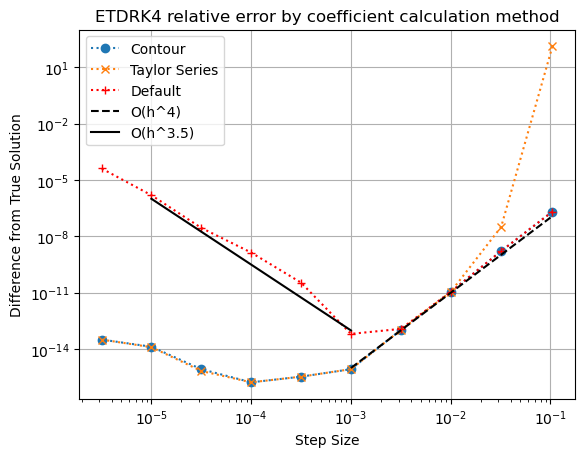

In [41]:
plt.loglog(Test_H, Error_Vec3, ':o', label = "Contour")
plt.loglog(Test_H, Error_Vec2, ':x', label = "Taylor Series")
plt.loglog(Test_H, Error_Vec1, 'r:+', label = "Default")
#plt.loglog([1e-2,1],[1e-11,1e-3],'k-')
## draw line from 1e-15 at h = 1e-3 to 1e-7 at h = 1e-1
plt.loglog([1e-3,1e-1],[1e-15,1e-7],'k--', label = "O(h^4)")
## draw line showing decoherence 
plt.loglog([1e-3,1e-5],[1e-13,1e-6],'k-', label = "O(h^3.5)")



plt.xlabel("Step Size")
plt.ylabel("Difference from True Solution")
plt.title("ETDRK4 relative error by coefficient calculation method")
plt.legend()
plt.grid()

In [42]:
Error_Vec1[-2]

np.float64(1.5462813653442306e-06)